In [1]:

import PIL
import PIL.Image
import tensorflow as tf
import pathlib

import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_dir = pathlib.Path('Data/Processed_data')
print(data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

Data\Processed_data
3845


In [3]:
batch_size = 6
img_height = 244
img_width = 244

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3845 files belonging to 2 classes.
Using 2692 files for training.
Found 3845 files belonging to 2 classes.
Using 1153 files for validation.


In [ ]:
import os
import json

# Create model save directory
os.makedirs('Export', exist_ok=True)

# Load best hyperparameters from JSON (created by cnn_train.py)
params_file = 'Export/best_hyperparameters.json'
if os.path.exists(params_file):
    print(f"✓ Loading best hyperparameters from {params_file}")
    with open(params_file, 'r') as f:
        best_params = json.load(f)
    
    filters_base = best_params['hyperparameters']['filters_base']
    dropout_rate = best_params['hyperparameters']['dropout']
    learning_rate = best_params['hyperparameters']['learning_rate']
    
    print("\n✓ Best hyperparameters loaded:")
    print(f"  Filters Base: {filters_base}")
    print(f"  Dropout Rate: {dropout_rate}")
    print(f"  Learning Rate: {learning_rate}")
    print(f"  Previous Fold Accuracy: {best_params['metrics']['accuracy']:.4f}")
else:
    print(f"⚠ Warning: {params_file} not found. Using default parameters.")
    # Best hyperparameters from tuning (defaults)
    filters_base = 32
    dropout_rate = 0.25
    learning_rate = 0.0005

num_classes = 2

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  
  # Block 1
  tf.keras.layers.Conv2D(filters_base, 3, activation='relu', padding='same'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(dropout_rate),
  
  # Block 2
  tf.keras.layers.Conv2D(filters_base * 2, 3, activation='relu', padding='same'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(dropout_rate),
  
  # Block 3
  tf.keras.layers.Conv2D(filters_base * 4, 3, activation='relu', padding='same'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(dropout_rate),
  
  # Dense layers
  tf.keras.layers.Flatten(), 
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Dropout(dropout_rate),
  tf.keras.layers.Dense(num_classes, activation='sigmoid')
])

print("\nModel architecture created with best parameters:")

In [ ]:
model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

In [ ]:
# Define callback to stop at 90% accuracy
class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, threshold=0.90):
        super().__init__()
        self.threshold = threshold
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_accuracy = logs.get('val_accuracy')
        if val_accuracy is not None and val_accuracy >= self.threshold:
            print(f"\n✓ Validation accuracy {val_accuracy:.4f} >= {self.threshold:.4f}")
            print("✓ Stopping training early!")
            self.model.stop_training = True

# Train model
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=40,
  callbacks=[
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    AccuracyThresholdCallback(threshold=0.90)
  ]
)

Epoch 1/4
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.7816 - loss: 0.4817 - val_accuracy: 0.8708 - val_loss: 0.3283
Epoch 2/4
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.9146 - loss: 0.2174 - val_accuracy: 0.8187 - val_loss: 0.4937
Epoch 3/4
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.9703 - loss: 0.0815 - val_accuracy: 0.9471 - val_loss: 0.1440
Epoch 4/4
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.9900 - loss: 0.0341 - val_accuracy: 0.9748 - val_loss: 0.0949


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 242, 242, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 121, 121, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 119, 119, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 59, 59, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,833,320 (18.44 MB)

 Trainable params: 1,611,106 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,222,214 (12.29 MB)

In [8]:
model.evaluate(
  val_ds
)

193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9748 - loss: 0.0949


[0.09486716240644455, 0.974848210811615]

In [ ]:
# Export final trained model
print("Saving trained model...")
model.save('Export/ot_model.keras')
print("✓ Model saved to Export/ot_model.keras")

# Also save in SavedModel format for compatibility
model.save('Export/ot_model_saved')
print("✓ Model also saved as SavedModel format to Export/ot_model_saved")

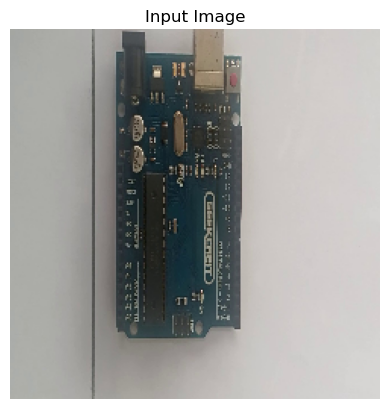

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Logits: [[-7.061465   3.9418464]]
Probabilities: [1.6646212e-05 9.9998331e-01]
Predicted class index: 1
Predicted label: Pass_data
Confidence: 0.9999833


In [9]:
# img_path = "Data/F1_Test/F1_images/F1_Pass/F1_Horiz_00110.jpg"
img_path = "Data/Processed_data/Pass_data/Pass_env2_00019.jpg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

logits = model.predict(img_array)
probs = tf.nn.softmax(logits[0]).numpy()

pred_class = np.argmax(probs)
confidence = probs[pred_class]

print("Logits:", logits)
print("Probabilities:", probs)
print("Predicted class index:", pred_class)
print("Predicted label:", train_ds.class_names[pred_class])
print("Confidence:", confidence)

In [10]:
model.save("Export/ot_model.keras")

In [11]:
import os
os.makedirs("Export", exist_ok=True)

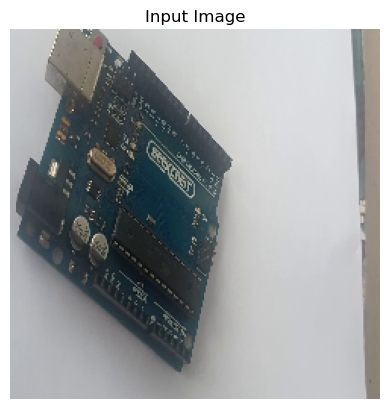

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Logits: [[ 6.0813055 -6.4701104]]
Probabilities: [9.999964e-01 3.539872e-06]
Predicted class index: 0
Predicted label: Fail_data
Confidence: 0.9999964


In [12]:
img_path = "Data/Processed_data/Fail_data/Fail_env2_00029.jpg"
# img_path = "Data/F1_Test/F1_images/F1_Fail/F1_None_00110.jpg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

loaded_model = tf.keras.models.load_model("Export/ot_model.keras")
logits = loaded_model.predict(img_array)
probs = tf.nn.softmax(logits[0]).numpy()

pred_class = np.argmax(probs)
confidence = probs[pred_class]

print("Logits:", logits)
print("Probabilities:", probs)
print("Predicted class index:", pred_class)
print("Predicted label:", train_ds.class_names[pred_class])
print("Confidence:", confidence)

In [ ]:
#!/usr/bin/env python3
"""
Hyperparameter Tuning with 2-Fold Cross-Validation
Tests different hyperparameter combinations and evaluates using stratified cross-validation
"""

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import pandas as pd

print("="*80)
print("HYPERPARAMETER TUNING WITH 2-FOLD CROSS-VALIDATION")
print("="*80)

# Prepare data for CV
all_labels = []
for class_name in data_dir.glob('*/'):
    for img_file in class_name.glob('*.jpg'):
        if 'Fail' in class_name.name:
            all_labels.append(0)
        else:
            all_labels.append(1)

y_all = np.array(all_labels)
print(f"\nTotal samples: {len(y_all)}")
print(f"Label distribution: {np.unique(y_all, return_counts=True)}")

# Define hyperparameters to tune (4 key ones)
hyperparameters = {
    'learning_rate': [0.001, 0.01],
    'num_filters': [32],
    'dense_units': [128],
    'dropout_rate': [0.2]
}

# Create combinations
param_combinations = []
for lr in hyperparameters['learning_rate']:
    for filters in hyperparameters['num_filters']:
        for units in hyperparameters['dense_units']:
            for dropout in hyperparameters['dropout_rate']:
                param_combinations.append({
                    'learning_rate': lr,
                    'num_filters': filters,
                    'dense_units': units,
                    'dropout_rate': dropout
                })

print(f"\nTesting {len(param_combinations)} hyperparameter combinations\n")

In [ ]:
# Perform 2-Fold Cross-Validation with Hyperparameter Tuning
results = []
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
fold_num = 0

print("Starting 2-Fold Cross-Validation...\n")

for train_idx, test_idx in skf.split(X, y_all):
    fold_num += 1
    print(f"\n{'='*80}")
    print(f"FOLD {fold_num}")
    print(f"{'='*80}")
    print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")
    
    # Split data for this fold
    X_train_indices = train_idx
    X_test_indices = test_idx
    
    for param_idx, params in enumerate(param_combinations):
        print(f"\n[{param_idx+1}/{len(param_combinations)}] Testing: lr={params['learning_rate']}, "
              f"filters={params['num_filters']}, units={params['dense_units']}")
        
        try:
            # Create data generators for this fold
            X_train_fold = []
            y_train_fold = []
            X_test_fold = []
            y_test_fold = []
            
            # Load training data for fold
            file_idx = 0
            for class_name in sorted(data_dir.glob('*/')):
                for img_file in sorted(class_name.glob('*.jpg')):
                    if 'Fail' in class_name.name:
                        label = 0
                    else:
                        label = 1
                    
                    img = tf.keras.utils.load_img(str(img_file), target_size=(img_height, img_width))
                    img_array = tf.keras.utils.img_to_array(img)
                    
                    if file_idx in X_train_indices:
                        X_train_fold.append(img_array)
                        y_train_fold.append(label)
                    else:
                        X_test_fold.append(img_array)
                        y_test_fold.append(label)
                    
                    file_idx += 1
            
            X_train_fold = np.array(X_train_fold) / 255.0
            y_train_fold = np.array(y_train_fold)
            X_test_fold = np.array(X_test_fold) / 255.0
            y_test_fold = np.array(y_test_fold)
            
            print(f"  Train samples: {len(X_train_fold)}, Test samples: {len(X_test_fold)}")
            
            # Build model with current hyperparameters
            cv_model = tf.keras.Sequential([
                tf.keras.layers.Rescaling(1./255),
                tf.keras.layers.Conv2D(params['num_filters'], 3, activation='relu'),
                tf.keras.layers.MaxPooling2D(),
                tf.keras.layers.Conv2D(params['num_filters'], 3, activation='relu'),
                tf.keras.layers.MaxPooling2D(),
                tf.keras.layers.Conv2D(params['num_filters'], 3, activation='relu'),
                tf.keras.layers.MaxPooling2D(),
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(params['dense_units'], activation='relu'),
                tf.keras.layers.Dropout(params['dropout_rate']),
                tf.keras.layers.Dense(num_classes)
            ])
            
            cv_model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
                loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy']
            )
            
            # Train
            history = cv_model.fit(
                X_train_fold, y_train_fold,
                epochs=3,
                batch_size=16,
                validation_data=(X_test_fold, y_test_fold),
                verbose=0
            )
            
            # Predict and evaluate
            y_pred_probs = cv_model.predict(X_test_fold, verbose=0)
            y_pred = np.argmax(y_pred_probs, axis=1)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test_fold, y_pred)
            recall = recall_score(y_test_fold, y_pred, average='binary', zero_division=0)
            precision = precision_score(y_test_fold, y_pred, average='binary', zero_division=0)
            f1 = f1_score(y_test_fold, y_pred, average='binary', zero_division=0)
            
            print(f"  Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1: {f1:.4f}")
            
            results.append({
                'fold': fold_num,
                'learning_rate': params['learning_rate'],
                'num_filters': params['num_filters'],
                'dense_units': params['dense_units'],
                'dropout_rate': params['dropout_rate'],
                'accuracy': accuracy,
                'recall': recall,
                'precision': precision,
                'f1_score': f1
            })
            
            del cv_model
            tf.keras.backend.clear_session()
            
        except Exception as e:
            print(f"  Error: {e}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(f"\n\n{'='*80}")
print("RESULTS SUMMARY")
print(f"{'='*80}")
print(results_df.to_string())

In [ ]:
# Generate Classification Summary Report
print("\n\n" + "="*80)
print("FOLD 1 RESULTS")
print("="*80)
fold1_results = results_df[results_df['fold'] == 1]
if not fold1_results.empty:
    best_fold1 = fold1_results.loc[fold1_results['accuracy'].idxmax()]
    print(f"\nBest Configuration (by Accuracy):")
    print(f"  Learning Rate: {best_fold1['learning_rate']}")
    print(f"  Num Filters: {best_fold1['num_filters']}")
    print(f"  Dense Units: {best_fold1['dense_units']}")
    print(f"  Dropout Rate: {best_fold1['dropout_rate']}")
    print(f"\nMetrics:")
    print(f"  Accuracy:  {best_fold1['accuracy']:.4f}")
    print(f"  Recall:    {best_fold1['recall']:.4f}")
    print(f"  Precision: {best_fold1['precision']:.4f}")
    print(f"  F1 Score:  {best_fold1['f1_score']:.4f}")

print("\n" + "="*80)
print("FOLD 2 RESULTS")
print("="*80)
fold2_results = results_df[results_df['fold'] == 2]
if not fold2_results.empty:
    best_fold2 = fold2_results.loc[fold2_results['accuracy'].idxmax()]
    print(f"\nBest Configuration (by Accuracy):")
    print(f"  Learning Rate: {best_fold2['learning_rate']}")
    print(f"  Num Filters: {best_fold2['num_filters']}")
    print(f"  Dense Units: {best_fold2['dense_units']}")
    print(f"  Dropout Rate: {best_fold2['dropout_rate']}")
    print(f"\nMetrics:")
    print(f"  Accuracy:  {best_fold2['accuracy']:.4f}")
    print(f"  Recall:    {best_fold2['recall']:.4f}")
    print(f"  Precision: {best_fold2['precision']:.4f}")
    print(f"  F1 Score:  {best_fold2['f1_score']:.4f}")

# Summary across folds
print("\n" + "="*80)
print("CROSS-FOLD PERFORMANCE SUMMARY")
print("="*80)
print(f"\nAccuracy  - Mean: {results_df['accuracy'].mean():.4f}, Std: {results_df['accuracy'].std():.4f}")
print(f"Recall    - Mean: {results_df['recall'].mean():.4f}, Std: {results_df['recall'].std():.4f}")
print(f"Precision - Mean: {results_df['precision'].mean():.4f}, Std: {results_df['precision'].std():.4f}")
print(f"F1 Score  - Mean: {results_df['f1_score'].mean():.4f}, Std: {results_df['f1_score'].std():.4f}")

# Find overall best configuration
best_overall = results_df.loc[results_df['accuracy'].idxmax()]
print(f"\n{'='*80}")
print("OVERALL BEST CONFIGURATION")
print(f"{'='*80}")
print(f"\nBest Configuration (by Mean Accuracy):")
print(f"  Learning Rate: {best_overall['learning_rate']}")
print(f"  Num Filters: {best_overall['num_filters']}")
print(f"  Dense Units: {best_overall['dense_units']}")
print(f"  Dropout Rate: {best_overall['dropout_rate']}")
print(f"  Fold: {int(best_overall['fold'])}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {best_overall['accuracy']:.4f}")
print(f"  Recall:    {best_overall['recall']:.4f}")
print(f"  Precision: {best_overall['precision']:.4f}")
print(f"  F1 Score:  {best_overall['f1_score']:.4f}")

print("\n✓ Hyperparameter tuning with 2-fold cross-validation complete!")